# Kennicott Glacier: what mass-balance profile gives zero net mass balance?

This notebook works toward the question: **given the actual shape of Kennicott
Glacier (its area-elevation distribution, i.e. hypsometry), what surface
mass-balance-vs-elevation profiles `b(z)` produce zero net (glacier-wide)
mass balance?**

Steps:

1. Download the RGI (Randolph Glacier Inventory) Region 01 - Alaska outlines,
   select the Kennicott (RGI60-01.15645) and Root (RGI60-01.26722) Glacier
   outlines, and merge them into a single outline (Root is a tributary that
   joins Kennicott's main trunk).
2. Auto-download the Copernicus 30 m (COP30) DEM tiles covering a broad
   bounding box around that merged outline, mosaic them, and reproject into
   UTM Zone 7N.
3. Subset/clip the DEM to the merged Kennicott + Root outline.
4. Build the combined glacier's hypsometry (area per elevation band).
5. Define a parametric mass-balance profile `b(z)` (piecewise-linear, matched
   to the elevation-dependent surface mass balance parameterization used in
   PISM for this glacier) and solve for the parameter combinations
   (equilibrium-line altitude, balance gradients) that zero out the
   area-weighted net balance.


## 1. Imports and configuration

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.merge import merge as rio_merge
from rasterio.plot import plotting_extent
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import mapping
import requests
from scipy.optimize import brentq

# Project directory (this notebook's folder)
PROJ_DIR = Path.cwd()

# Local cache for downloaded RGI + DEM data (kept out of git via .gitignore below)
DATA_DIR = PROJ_DIR / "data_downloads"
DATA_DIR.mkdir(exist_ok=True)
COP30_TILE_DIR = DATA_DIR / "cop30_tiles"
COP30_TILE_DIR.mkdir(exist_ok=True)

# RGI v6.0 region 01 (Alaska), mirrored (no-auth) by OGGM from the official
# GLIMS/RGI distribution.
RGI01_URL = (
    "https://cluster.klima.uni-bremen.de/~oggm/rgi/www.glims.org/RGI/"
    "rgi60_files/01_rgi60_Alaska.zip"
)
RGI01_ZIP = DATA_DIR / "01_rgi60_Alaska.zip"
RGI01_DIR = DATA_DIR / "01_rgi60_Alaska"

# RGI IDs for Kennicott and (tributary) Root Glacier (verified below by name match too)
KENNICOTT_RGI_ID = "RGI60-01.15645"
ROOT_RGI_ID = "RGI60-01.26722"

# Copernicus GLO-30 (COP30) DEM, public/no-auth AWS Open Data bucket
COP30_BASE_URL = "https://copernicus-dem-30m.s3.amazonaws.com"
DEM_BBOX_BUFFER_DEG = 0.15   # degrees padding around the glacier outline when selecting DEM tiles
DEM_DST_CRS = "EPSG:32607"   # UTM zone 7N -- correct zone for this longitude
DEM_TARGET_RES = 30.0        # metres

# Auto-downloaded, mosaicked + reprojected DEM (built in step 3 below)
DEM_PATH = PROJ_DIR / "kennicott_root_COP30_DEM_epsg32607.tif"

RHO_ICE = 910.0  # kg/m^3, ice density used to convert kg/m^2 -> m ice-equivalent


## 2. Download RGI Region 01 (Alaska), select Kennicott + Root Glacier, and merge outlines

In [2]:
if not RGI01_DIR.exists():
    if not RGI01_ZIP.exists():
        print(f"Downloading RGI v6.0 Region 01 (Alaska) from:\n  {RGI01_URL}")
        resp = requests.get(RGI01_URL, timeout=120)
        resp.raise_for_status()
        RGI01_ZIP.write_bytes(resp.content)
        print(f"Downloaded {RGI01_ZIP.stat().st_size / 1e6:.1f} MB.")
    else:
        print("Zip already cached locally, skipping download.")

    RGI01_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(RGI01_ZIP) as zf:
        zf.extractall(RGI01_DIR)
    print(f"Extracted to {RGI01_DIR}")
else:
    print("RGI Region 01 already downloaded and extracted, skipping.")


RGI Region 01 already downloaded and extracted, skipping.


In [3]:
rgi01_shp = next(RGI01_DIR.glob("*.shp"))
rgi01 = gpd.read_file(rgi01_shp)
print(f"Loaded {len(rgi01)} glacier outlines for RGI Region 01 (Alaska), CRS={rgi01.crs}")

# Select Kennicott and Root Glaciers -- match by RGIId, with names as a sanity check
selected = rgi01[rgi01["RGIId"].isin([KENNICOTT_RGI_ID, ROOT_RGI_ID])].copy()
assert len(selected) == 2, f"Expected 2 matches for {KENNICOTT_RGI_ID}/{ROOT_RGI_ID}, got {len(selected)}"
print(selected[["RGIId", "Name", "Area", "CenLon", "CenLat", "Zmin", "Zmax", "Zmed"]])

names_lower = selected["Name"].str.lower()
assert names_lower.str.contains("kennicott").any(), "Kennicott not found -- check RGIId."
assert names_lower.str.contains("root").any(), "Root not found -- check RGIId."

# Merge (dissolve) the two outlines into a single polygon -- Root is a
# tributary that joins Kennicott's main trunk, so the combined outline gives
# one continuous ice mask to clip the DEM against.
kennicott_root = gpd.GeoDataFrame(
    {"Name": ["Kennicott + Root"]}, geometry=[selected.union_all()], crs=selected.crs
)
combined_rgi_area_km2 = selected["Area"].sum()
print(f"\nCombined (Kennicott + Root) RGI area: {combined_rgi_area_km2:.2f} km^2")


Loaded 27108 glacier outlines for RGI Region 01 (Alaska), CRS=EPSG:4326
                RGIId               Name     Area      CenLon     CenLat  \
15640  RGI60-01.15645  Kennicott Glacier  292.531 -143.043365  61.572723   
26717  RGI60-01.26722       Root Glacier   82.477 -142.899000  61.633000   

       Zmin  Zmax  Zmed  
15640   399  4432  1826  
26717   570  3952  2190  

Combined (Kennicott + Root) RGI area: 375.01 km^2


## 3. Auto-download the Copernicus 30 m DEM (COP30) around Kennicott + Root Glacier

Rather than depending on a manually-provided DEM file, this step downloads
the public, no-auth-required Copernicus GLO-30 (COP30) tiles directly from
the [AWS Open Data bucket](https://registry.opendata.aws/copernicus-dem/),
covering a bounding box padded by `DEM_BBOX_BUFFER_DEG` (0.15&deg;, roughly
10-15 km at this latitude) around the merged Kennicott + Root outline. The
tiles are mosaicked together and reprojected into UTM Zone 7N (EPSG:32607)
at 30 m resolution. Both the raw tiles and the final mosaic are cached
locally, so re-running the notebook doesn't re-download anything.


In [4]:
minx, miny, maxx, maxy = kennicott_root.total_bounds  # EPSG:4326 (lon/lat)
bbox = (
    minx - DEM_BBOX_BUFFER_DEG,
    miny - DEM_BBOX_BUFFER_DEG,
    maxx + DEM_BBOX_BUFFER_DEG,
    maxy + DEM_BBOX_BUFFER_DEG,
)
print(f"DEM download bounding box (lon/lat): "
      f"({bbox[0]:.3f}, {bbox[1]:.3f}) to ({bbox[2]:.3f}, {bbox[3]:.3f})")


def cop30_tile_name(lat0, lon0):
    """COP30 tile name for the 1x1 degree cell whose SW corner is (lat0, lon0)."""
    ns = "N" if lat0 >= 0 else "S"
    ew = "E" if lon0 >= 0 else "W"
    return f"Copernicus_DSM_COG_10_{ns}{abs(lat0):02d}_00_{ew}{abs(lon0):03d}_00_DEM"


lat0_range = range(int(np.floor(bbox[1])), int(np.floor(bbox[3])) + 1)
lon0_range = range(int(np.floor(bbox[0])), int(np.floor(bbox[2])) + 1)
tile_names = [cop30_tile_name(la, lo) for la in lat0_range for lo in lon0_range]
print(f"COP30 tiles needed ({len(tile_names)}): {tile_names}")

tile_paths = []
for tile in tile_names:
    tile_path = COP30_TILE_DIR / f"{tile}.tif"
    if not tile_path.exists():
        url = f"{COP30_BASE_URL}/{tile}/{tile}.tif"
        print(f"Downloading {url}")
        resp = requests.get(url, timeout=180)
        resp.raise_for_status()
        tile_path.write_bytes(resp.content)
    else:
        print(f"{tile}.tif already cached, skipping download.")
    tile_paths.append(tile_path)


DEM download bounding box (lon/lat): (-143.547, 61.289) to (-142.678, 61.899)
COP30 tiles needed (2): ['Copernicus_DSM_COG_10_N61_00_W144_00_DEM', 'Copernicus_DSM_COG_10_N61_00_W143_00_DEM']
Copernicus_DSM_COG_10_N61_00_W144_00_DEM.tif already cached, skipping download.
Copernicus_DSM_COG_10_N61_00_W143_00_DEM.tif already cached, skipping download.


In [5]:
if DEM_PATH.exists():
    print(f"{DEM_PATH.name} already exists, skipping mosaic/reprojection.")
else:
    with rasterio.open(tile_paths[0]) as s:
        mosaic_crs = s.crs

    mosaic_arr, mosaic_transform = rio_merge(tile_paths)
    mosaic_height, mosaic_width = mosaic_arr.shape[-2:]
    left, bottom, right, top = rasterio.transform.array_bounds(
        mosaic_height, mosaic_width, mosaic_transform
    )

    dst_transform, dst_width, dst_height = calculate_default_transform(
        mosaic_crs, DEM_DST_CRS, mosaic_width, mosaic_height,
        left, bottom, right, top, resolution=DEM_TARGET_RES,
    )
    dst_profile = {
        "driver": "GTiff",
        "height": dst_height,
        "width": dst_width,
        "count": 1,
        "dtype": mosaic_arr.dtype,
        "crs": DEM_DST_CRS,
        "transform": dst_transform,
        "nodata": 0.0,
    }
    with rasterio.open(DEM_PATH, "w", **dst_profile) as dst:
        reproject(
            source=mosaic_arr[0],
            destination=rasterio.band(dst, 1),
            src_transform=mosaic_transform,
            src_crs=mosaic_crs,
            dst_transform=dst_transform,
            dst_crs=DEM_DST_CRS,
            dst_nodata=0.0,
            resampling=Resampling.bilinear,
        )
    print(f"Wrote mosaicked + reprojected DEM to {DEM_PATH.name} "
          f"({dst_width} x {dst_height} px at {DEM_TARGET_RES:.0f} m)")


kennicott_root_COP30_DEM_epsg32607.tif already exists, skipping mosaic/reprojection.


## 4. Load the DEM

Load the auto-downloaded, mosaicked DEM built in step 3 above
(`kennicott_root_COP30_DEM_epsg32607.tif`), already reprojected into UTM
Zone 7N (EPSG:32607) at 30 m resolution, with `nodata = 0.0`. Working in
this projected CRS gives equal-area, metre-sized pixels for the hypsometry
calculation later on (pixel areas in geographic/degree coordinates would
otherwise vary with latitude).


In [6]:
with rasterio.open(DEM_PATH) as src:
    dem_crs = src.crs
    dem_bounds = src.bounds
    dem_transform = src.transform
    dem_nodata = src.nodata
    dem_raw = src.read(1)

print("DEM CRS:             ", dem_crs)
print("DEM bounds (m):      ", dem_bounds)
print("Pixel size (m):      ", dem_transform.a, -dem_transform.e)
print("Shape (rows, cols):  ", dem_raw.shape)
print("Nodata value:        ", dem_nodata)

assert dem_crs.is_projected, f"Expected a projected (metric) CRS, got {dem_crs}"
DST_CRS = dem_crs  # used below to reproject the RGI polygon to match

# Basic data-quality guard: catch an empty/placeholder DEM early with a clear
# message, rather than a cryptic failure several cells downstream.
finite = dem_raw[dem_raw != dem_nodata]
elev_range = finite.max() - finite.min() if finite.size else 0
print("Elevation range (m):  ", finite.min() if finite.size else float("nan"),
      "to", finite.max() if finite.size else float("nan"))

assert finite.size and elev_range > 100, (
    f"DEM looks empty or degenerate (elevation range = {elev_range:.1f} m over "
    f"{finite.size} valid pixels). Kennicott spans ~400-4400 m, so this file "
    "does not contain real elevation data -- re-export/replace it before continuing."
)


DEM CRS:              EPSG:32607
DEM bounds (m):       BoundingBox(left=337767.4748575728, bottom=6763198.734240154, right=447627.4748575728, top=6877828.734240154)
Pixel size (m):       30.0 30.0
Shape (rows, cols):   (3821, 3662)
Nodata value:         0.0
Elevation range (m):   181.066 to 4987.448


## 5. Subset the DEM by the merged Kennicott + Root Glacier outline

In [7]:
# Reproject the merged glacier polygon into the DEM's CRS (UTM 7N)
outline_utm = kennicott_root.to_crs(DST_CRS)
geom_utm = [mapping(outline_utm.iloc[0].geometry)]

with rasterio.open(DEM_PATH) as src:
    clipped_arr, clipped_transform = rio_mask(
        src, geom_utm, crop=True, filled=True, nodata=np.nan
    )
    clipped_profile = src.profile.copy()

clipped_arr = clipped_arr[0].astype("float64")
# Also treat the source's own nodata sentinel (0.0) as invalid, not just the
# area outside the polygon (rio_mask only fills the exterior).
clipped_arr[clipped_arr == dem_nodata] = np.nan
clipped_profile.update(
    height=clipped_arr.shape[0],
    width=clipped_arr.shape[1],
    transform=clipped_transform,
    dtype="float64",
    nodata=np.nan,
)

valid = np.isfinite(clipped_arr)
print(f"Clipped raster shape:   {clipped_arr.shape}")
print(f"Valid (on-glacier) px:  {valid.sum()} of {clipped_arr.size}")
print(f"Elevation range (m):    {clipped_arr[valid].min():.0f} to {clipped_arr[valid].max():.0f}")

pixel_area_m2 = abs(clipped_transform.a * clipped_transform.e)
glacier_area_km2 = valid.sum() * pixel_area_m2 / 1e6
print(f"Pixel area:             {pixel_area_m2:.1f} m^2")
print(f"DEM-derived area:       {glacier_area_km2:.2f} km^2  (combined RGI inventory area: {combined_rgi_area_km2:.2f} km^2)")


Clipped raster shape:   (1170, 995)
Valid (on-glacier) px:  416473 of 1164150
Elevation range (m):    408 to 4960
Pixel area:             900.0 m^2
DEM-derived area:       374.83 km^2  (combined RGI inventory area: 375.01 km^2)


In [8]:
# Write the clipped DEM to disk alongside the source DEM
clip_path = PROJ_DIR / "kennicott_glacier_DEM_clip_UTM7N.tif"
with rasterio.open(clip_path, "w", **clipped_profile) as dst:
    dst.write(clipped_arr, 1)
print(f"Wrote clipped DEM to {clip_path.name}")


Wrote clipped DEM to kennicott_glacier_DEM_clip_UTM7N.tif


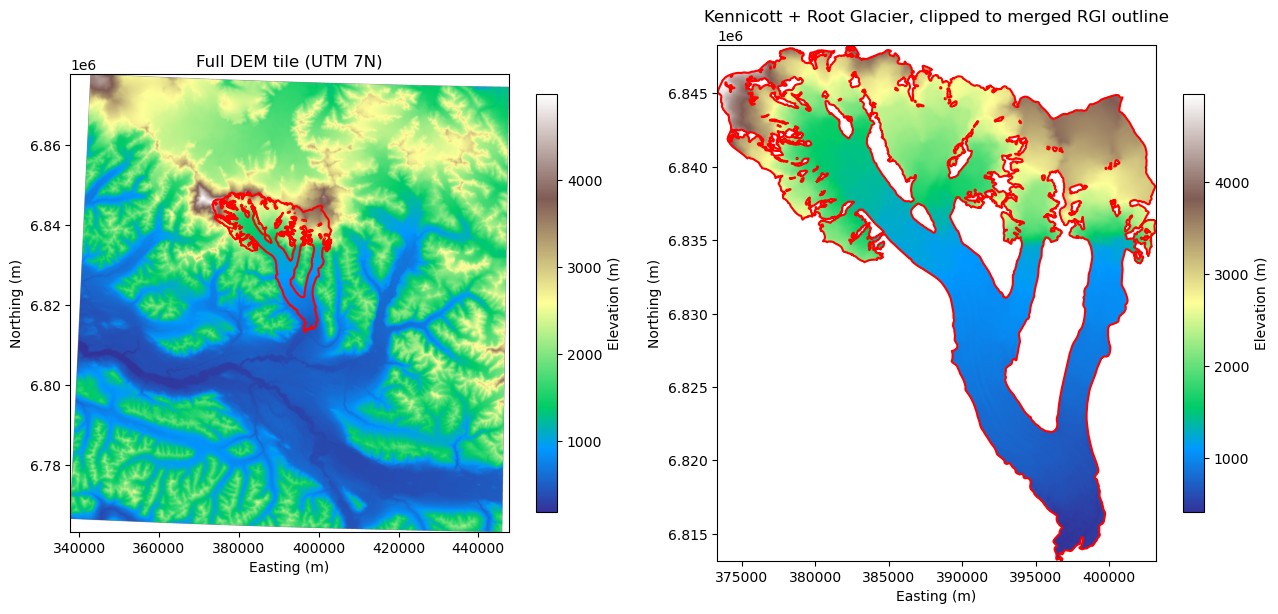

In [9]:
def plot_dem_overview(dem_path, dem_nodata, outline_utm, clipped_arr, clipped_transform):
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    with rasterio.open(dem_path) as dem_ds:
        dem_full = np.ma.masked_equal(dem_ds.read(1), dem_nodata)
        extent_full = plotting_extent(dem_ds)
    im0 = axes[0].imshow(dem_full, cmap="terrain", extent=extent_full)
    axes[0].set_title("Full DEM tile (UTM 7N)")
    fig.colorbar(im0, ax=axes[0], label="Elevation (m)", shrink=0.8)
    outline_utm.boundary.plot(ax=axes[0], color="red", linewidth=1.5)

    im1 = axes[1].imshow(
        clipped_arr,
        cmap="terrain",
        extent=(
            clipped_transform.c,
            clipped_transform.c + clipped_arr.shape[1] * clipped_transform.a,
            clipped_transform.f + clipped_arr.shape[0] * clipped_transform.e,
            clipped_transform.f,
        ),
    )
    outline_utm.boundary.plot(ax=axes[1], color="red", linewidth=1.5)
    axes[1].set_title("Kennicott + Root Glacier, clipped to merged RGI outline")
    fig.colorbar(im1, ax=axes[1], label="Elevation (m)", shrink=0.8)
    for ax in axes:
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()


plot_dem_overview(DEM_PATH, dem_nodata, outline_utm, clipped_arr, clipped_transform)


## 6. Hypsometry: area per elevation band

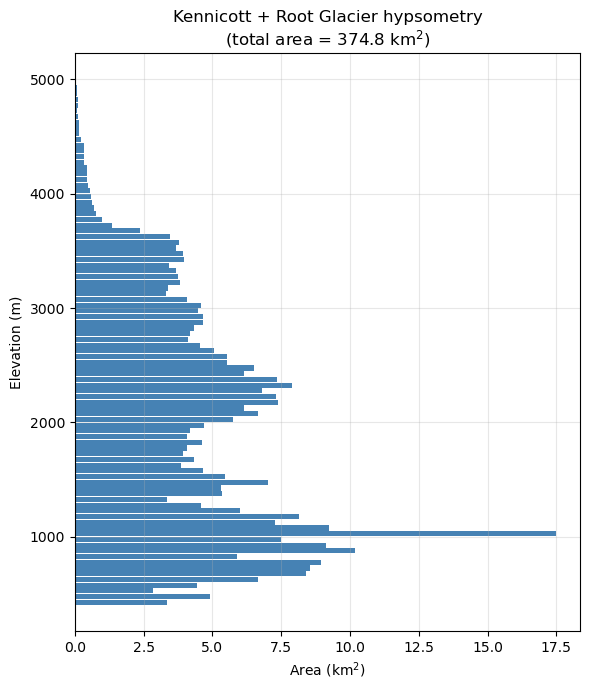

In [10]:
elevations = clipped_arr[valid]

BIN_WIDTH = 50.0  # metres
bin_start = np.floor(elevations.min() / BIN_WIDTH) * BIN_WIDTH
bin_stop = np.ceil(elevations.max() / BIN_WIDTH) * BIN_WIDTH
bin_stop = max(bin_stop, bin_start + BIN_WIDTH)  # guard against a degenerate (near-zero) elevation range
bin_edges = np.arange(bin_start, bin_stop + BIN_WIDTH, BIN_WIDTH)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

counts, _ = np.histogram(elevations, bins=bin_edges)
area_km2_per_bin = counts * pixel_area_m2 / 1e6
total_area_km2 = area_km2_per_bin.sum()


def plot_hypsometry(bin_centers, area_km2_per_bin, bin_width, total_area_km2):
    """Area (km^2) as a function of elevation (m) -- the glacier's hypsometry."""
    fig, ax = plt.subplots(figsize=(6, 7))
    ax.barh(bin_centers, area_km2_per_bin, height=bin_width * 0.9, color="steelblue")
    ax.set_xlabel("Area (km$^2$)")
    ax.set_ylabel("Elevation (m)")
    ax.set_title(f"Kennicott + Root Glacier hypsometry\n(total area = {total_area_km2:.1f} km$^2$)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_hypsometry(bin_centers, area_km2_per_bin, BIN_WIDTH, total_area_km2)


## 7. Mass balance profile: reference parameterization

The cell below records the elevation-dependent surface mass balance (SMB)
configuration Bruno is using to drive PISM for Kennicott Glacier (see the
[PISM manual, `surface.elevation_dependent`
section](https://www.pism.io/docs/manual/parameters/index.html#surface.elevation_dependent.T_min)).
It defines a piecewise-linear `M(z)` profile: flat at `M_limit_min` below
`z_M_min`, ramping linearly through 0 at `z_ELA`, up to `M_max` at `z_M_max`,
then flat at `M_limit_max` above.


In [11]:
"""
Config file that Bruno is using to drive the surface mass balance of
Kennicott Glacier. This is per the instructions in
https://www.pism.io/docs/manual/parameters/index.html#surface.elevation_dependent.T_min

[surface.options.elevation_dependent]

'surface.models' = "elevation_dependent"

'surface.elevation_dependent.z_M_min' = 700
'surface.elevation_dependent.M_min' = -8.80         # = -8000 kg/m^2 / 910 kg/m^3
'surface.elevation_dependent.z_ELA' = 1750
'surface.elevation_dependent.z_M_max' = 2200
'surface.elevation_dependent.M_max' = 2.42
'surface.elevation_dependent.M_limit_min' = -8.80
'surface.elevation_dependent.M_limit_max' = 2.42
"""


'\nConfig file that Bruno is using to drive the surface mass balance of\nKennicott Glacier. This is per the instructions in\nhttps://www.pism.io/docs/manual/parameters/index.html#surface.elevation_dependent.T_min\n\n[surface.options.elevation_dependent]\n\n\'surface.models\' = "elevation_dependent"\n\n\'surface.elevation_dependent.z_M_min\' = 700\n\'surface.elevation_dependent.M_min\' = -8.80         # = -8000 kg/m^2 / 910 kg/m^3\n\'surface.elevation_dependent.z_ELA\' = 1750\n\'surface.elevation_dependent.z_M_max\' = 2200\n\'surface.elevation_dependent.M_max\' = 2.42\n\'surface.elevation_dependent.M_limit_min\' = -8.80\n\'surface.elevation_dependent.M_limit_max\' = 2.42\n'

In [12]:
# PISM elevation_dependent parameters (units: m ice-equivalent per year)
# PISM_PARAMS = dict( # original params that Bruno was using
#     z_M_min=700.0,
#     M_min=-8.80,
#     z_ELA=1750.0,
#     z_M_max=2200.0,
#     M_max=2.42,
#     M_limit_min=-8.80,
#     M_limit_max=2.42,
# )

# PISM elevation_dependent parameters (units: m ice-equivalent per year)
# Tim's best read of the chart
PISM_PARAMS = dict(
    z_M_min     =  700.0,
    M_min       = -7000 / RHO_ICE,
    z_ELA       =  1750.0,
    z_M_max     =  2250.0,
    M_max       =  2500 / RHO_ICE,
    M_limit_min = -1550 / RHO_ICE,
    M_limit_max =  2500 / RHO_ICE,
)

### How well-constrained are these parameters, really?

**`z_ELA` and the shape near it are locally supported; `z_M_max`/`M_max` are
not.** Petersen et al. (2025) report direct field observations on Kennicott
Glacier: an ELA near 1750 m (matching `z_ELA` here), and a specific-mass-balance
observation of about 2000 kg/m^2/yr (~2.20 m ice-eq/yr with `RHO_ICE` = 910
kg/m^3) at 2200 m elevation. That single high-elevation point, combined with
the ELA, is real local evidence -- it's what anchors this profile's
accumulation gradient.

But nothing in the local record pins down **where the accumulation-zone
mass balance actually stops increasing with elevation, or what value it
plateaus at** -- i.e. `z_M_max` (2250 m) and `M_max` here are an assumption
used to close out the parameterization above the one observed point, not an
observed or independently-constrained quantity for this glacier. The same
goes for `z_M_min` and `M_min`/`M_limit_min` describing the low-elevation
end.

The literature review below is regional context for how far above the ELA
such a plateau *can* plausibly sit on nearby high peaks -- useful for
sanity-checking whether 2250 m is a reasonable guess, but it is not evidence
about Kennicott + Root specifically.

- **Mt. Logan (5959 m, St. Elias Mtns)** has the most direct, quantified
  evidence of a true plateau: Keeler (1969) found annual accumulation of
  ~0.65 m w.e./yr that is essentially *constant* across the huge span
  3350-5400 m -- i.e. the accumulation-elevation gradient there effectively
  vanishes above roughly **3300-3400 m**. Goto-Azuma et al. (2006)
  independently found a "staircase" step in snow chemistry/moisture-source
  signal between ~3200 m and 4000-5000 m on Logan, consistent with a regime
  change around that same elevation.
- **Denali (6190 m) and Mt. Hunter/Begguya (4442 m)** ice-core studies
  (Winski et al. 2017, 2018; Kahiltna Pass firn cores) don't provide an
  explicit two-site vertical gradient the way Logan's data does -- each site
  (Kahiltna Pass ~3100 m: ~0.8 m ice-eq/yr; Mt. Hunter col ~3900 m: ~1.4 m
  w.e./yr) is treated as a locally-representative constant rather than part
  of a systematic elevation-gradient study, so no plateau elevation can be
  cited for those peaks from the literature reviewed here.
- More generally, accumulation-zone mass-balance gradients are well known to
  be shallower than ablation-zone gradients on essentially all glaciers
  (Kuhn, 1984), independent of any specific elevation.

Taken together: Kennicott + Root's assumed `z_M_max` (2250 m) is far below
the ~3300 m plateau elevation measured on Mt. Logan, which is at least
consistent with the general expectation that *some* flattening should occur
well below the summit -- but that's a plausibility check, not a
verification. Confirming `z_M_max`/`M_max` for this glacier would need
additional high-elevation stake or geodetic data on Kennicott or Root
themselves.

**References**
- Petersen, E.I., Hock, R., Loso, M.G., Guo, W., Markovsky, C., Yang, R.,
  Han, H., Shangguan, D., & Kang, S. (2025). Multi-Year Glaciological and
  Meteorological Observations on Debris-Covered Kennicott Glacier, Alaska,
  2016-2023. *Geoscience Data Journal*, 12(4), e70032.
- Keeler, C.M. (1969). Snow accumulation on Mount Logan, Yukon Territory,
  Canada. *Water Resources Research*, 5(3), 719-723.
- Goto-Azuma, K., Koerner, R.M., Demuth, M.N., & Watanabe, O. (2006). Seasonal
  and spatial variations of snow chemistry on Mount Logan, Yukon, Canada.
  *Annals of Glaciology*, 43, 177-186.
- Winski, D. et al. (2017). Industrial-age doubling of snow accumulation in
  the Alaska Range linked to tropical ocean warming. *Scientific Reports*, 7,
  17869.
- Winski, D. et al. (2018). A 400-year ice core melt layer record of
  summertime warming in the Alaska Range. *JGR Atmospheres*, 123.
- Kuhn, M. (1984). Mass-balance gradients and climatic change. *Journal of
  Glaciology*, 30(106).


Net specific balance with PISM SMB params (ELA = 1750 m): -0.599 m ice-eq/yr


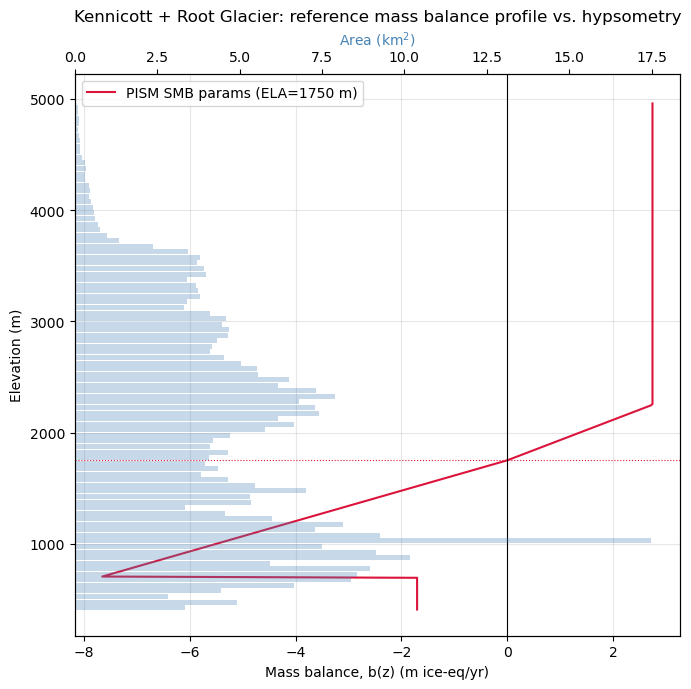

In [13]:
def mass_balance_profile(z, z_M_min, M_min, z_ELA, z_M_max, M_max,
                          M_limit_min, M_limit_max):
    """PISM's elevation_dependent surface mass balance, b(z).

    Piecewise-linear through (z_M_min, M_min) -> (z_ELA, 0) -> (z_M_max, M_max),
    clamped to M_limit_min / M_limit_max outside [z_M_min, z_M_max].
    """
    z = np.asarray(z, dtype=float)
    b = np.empty_like(z)

    below = z <= z_M_min
    ablation = (z > z_M_min) & (z <= z_ELA)
    accumulation = (z > z_ELA) & (z <= z_M_max)
    above = z > z_M_max

    b[below] = M_limit_min
    b[ablation] = M_min * (z_ELA - z[ablation]) / (z_ELA - z_M_min)
    b[accumulation] = M_max * (z[accumulation] - z_ELA) / (z_M_max - z_ELA)
    b[above] = M_limit_max
    return b


def net_specific_balance(bin_centers, area_km2_per_bin, **profile_kwargs):
    """Area-weighted net balance (m ice-eq/yr) over the hypsometry."""
    b = mass_balance_profile(bin_centers, **profile_kwargs)
    total_area = area_km2_per_bin.sum()
    return float(np.sum(b * area_km2_per_bin) / total_area)


B_net_pism = net_specific_balance(bin_centers, area_km2_per_bin, **PISM_PARAMS)
print(f"Net specific balance with PISM SMB params (ELA = {PISM_PARAMS['z_ELA']:.0f} m): "
      f"{B_net_pism:+.3f} m ice-eq/yr")


def plot_mass_balance_reference(elevations, pism_params, bin_centers, area_km2_per_bin, bin_width):
    """Reference mass balance profile b(z), with the hypsometry as a second (twinned) axis."""
    fig, ax1 = plt.subplots(figsize=(7, 7))

    z_plot = np.linspace(elevations.min(), elevations.max(), 400)
    ax1.plot(mass_balance_profile(z_plot, **pism_params), z_plot,
             color="crimson", label=f"PISM SMB params (ELA={pism_params['z_ELA']:.0f} m)")
    ax1.axvline(0, color="k", lw=0.8)
    ax1.axhline(pism_params["z_ELA"], color="crimson", lw=0.8, ls=":")
    ax1.set_xlabel("Mass balance, b(z) (m ice-eq/yr)")
    ax1.set_ylabel("Elevation (m)")
    ax1.legend(loc="upper left")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twiny()
    ax2.barh(bin_centers, area_km2_per_bin, height=bin_width * 0.9,
             color="steelblue", alpha=0.3, zorder=0)
    ax2.set_xlabel("Area (km$^2$)", color="steelblue")

    ax1.set_title("Kennicott + Root Glacier: reference mass balance profile vs. hypsometry")
    plt.tight_layout()
    plt.show()


plot_mass_balance_reference(elevations, PISM_PARAMS, bin_centers, area_km2_per_bin, BIN_WIDTH)


## 8. Solving for zero net mass balance

The two methods below each hold something specific and physically
meaningful fixed, and solve for what's needed to zero out the area-weighted
net balance:

1. **Uniform shift** -- keep every gradient and every breakpoint elevation
   exactly as specified, and translate the *entire* profile by a constant
   mass-balance offset `delta_b`. Every point on `b(z)` -- ablation ramp,
   accumulation ramp, and both plateaus -- moves sideways in the plot by the
   same amount; no slopes change.
2. **Sliding accumulation cap** -- keep the ablation zone (`z_M_min`, `M_min`,
   `z_ELA`) and the accumulation gradient exactly as specified, but let the
   cap point `(z_M_max, M_max)` slide up or down *along that same-slope
   line*. A higher cap extends the accumulation ramp further before it
   plateaus (more high-elevation accumulation contributes); a lower cap
   plateaus sooner.


In [14]:
# --- Method 1: uniform shift -----------------------------------------------
# Translating b(z) by a constant changes the area-weighted net balance by
# that same constant (the shift is linear), so the zero-balance offset has an
# exact closed form -- no root-finding needed.
delta_b_zero = -B_net_pism

# Elevation where the shifted profile crosses zero (for plotting only; the
# profile itself is unchanged in shape, just offset).
z_zero_shift = brentq(
    lambda z: mass_balance_profile(np.array([z]), **PISM_PARAMS)[0] + delta_b_zero,
    elevations.min() + 1, elevations.max() - 1,
)

B_check_shift = net_specific_balance(bin_centers, area_km2_per_bin, **PISM_PARAMS) + delta_b_zero

print("Method 1 -- uniform shift of the whole profile")
print(f"  PISM SMB params as-is:      net balance = {B_net_pism:+.3f} m ice-eq/yr")
print(f"  Shift required:             delta_b = {delta_b_zero:+.3f} m ice-eq/yr")
print(f"  Effective zero-balance elevation (where the shifted profile crosses 0): {z_zero_shift:.0f} m")
print(f"  -> net balance after shift: {B_check_shift:+.4f} m ice-eq/yr (should be ~0)")


Method 1 -- uniform shift of the whole profile
  PISM SMB params as-is:      net balance = -0.599 m ice-eq/yr
  Shift required:             delta_b = +0.599 m ice-eq/yr
  Effective zero-balance elevation (where the shifted profile crosses 0): 1668 m
  -> net balance after shift: +0.0000 m ice-eq/yr (should be ~0)


In [15]:
# --- Method 2: sliding accumulation cap -------------------------------------
# Keep the ablation zone (z_M_min, M_min, z_ELA) and the accumulation
# gradient fixed; slide the cap point (z_M_max, M_max) up/down along that
# same-slope line.
accum_gradient = PISM_PARAMS["M_max"] / (PISM_PARAMS["z_M_max"] - PISM_PARAMS["z_ELA"])


def make_accum_cap_params(z_m_max_new, base_params, accum_gradient):
    """Rebuild M_max/M_limit_max for a new z_M_max, holding the accumulation
    gradient (and everything below z_ELA) fixed."""
    m_max_new = accum_gradient * (z_m_max_new - base_params["z_ELA"])
    params = dict(base_params)
    params["z_M_max"] = z_m_max_new
    params["M_max"] = m_max_new
    params["M_limit_max"] = m_max_new
    return params


def net_balance_vs_accum_cap(z_m_max_new, base_params, accum_gradient, bin_centers, area_km2_per_bin):
    params = make_accum_cap_params(z_m_max_new, base_params, accum_gradient)
    return net_specific_balance(bin_centers, area_km2_per_bin, **params)


z_ela = PISM_PARAMS["z_ELA"]
z_m_max_hi = z_ela + 30 * (PISM_PARAMS["z_M_max"] - z_ela)
z_m_max_zero = brentq(
    net_balance_vs_accum_cap, z_ela + 1, z_m_max_hi,
    args=(PISM_PARAMS, accum_gradient, bin_centers, area_km2_per_bin),
)

accum_cap_params = make_accum_cap_params(z_m_max_zero, PISM_PARAMS, accum_gradient)
B_check_accum_cap = net_specific_balance(bin_centers, area_km2_per_bin, **accum_cap_params)

print("Method 2 -- accumulation cap slides along the fixed accumulation gradient")
print(f"  z_M_max: {z_m_max_zero:.0f} m (was {PISM_PARAMS['z_M_max']:.0f} m)")
print(f"  M_max:   {accum_cap_params['M_max']:+.3f} m ice-eq/yr (was {PISM_PARAMS['M_max']:+.3f} m ice-eq/yr)")
print(f"  -> net balance:            {B_check_accum_cap:+.4f} m ice-eq/yr (should be ~0)")


Method 2 -- accumulation cap slides along the fixed accumulation gradient
  z_M_max: 2592 m (was 2250 m)
  M_max:   +4.628 m ice-eq/yr (was +2.747 m ice-eq/yr)
  -> net balance:            -0.0000 m ice-eq/yr (should be ~0)


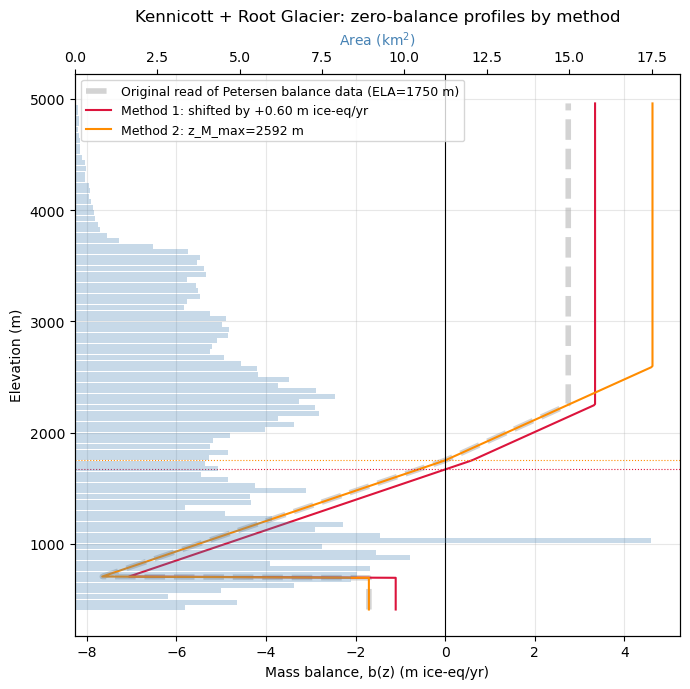

In [16]:
def plot_zero_balance_methods(elevations, pism_params, delta_b_zero, z_zero_shift,
                               accum_cap_params, bin_centers, area_km2_per_bin, bin_width):
    fig, ax1 = plt.subplots(figsize=(7, 7))

    z_plot = np.linspace(elevations.min(), elevations.max(), 400)
    ax1.plot(mass_balance_profile(z_plot, **pism_params), z_plot,
             color="lightgray", ls="--", lw=4, zorder=1,
             label=f"Original read of Petersen balance data (ELA={pism_params['z_ELA']:.0f} m)")
    ax1.plot(mass_balance_profile(z_plot, **pism_params) + delta_b_zero, z_plot,
             color="crimson", label=f"Method 1: shifted by {delta_b_zero:+.2f} m ice-eq/yr")
    ax1.plot(mass_balance_profile(z_plot, **accum_cap_params), z_plot,
             color="darkorange", label=f"Method 2: z_M_max={accum_cap_params['z_M_max']:.0f} m")

    ax1.axvline(0, color="k", lw=0.8)
    ax1.axhline(z_zero_shift, color="crimson", lw=0.8, ls=":")
    ax1.axhline(pism_params["z_ELA"], color="darkorange", lw=0.8, ls=":")
    ax1.set_xlabel("Mass balance, b(z) (m ice-eq/yr)")
    ax1.set_ylabel("Elevation (m)")
    ax1.legend(loc="upper left", fontsize=9)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twiny()
    ax2.barh(bin_centers, area_km2_per_bin, height=bin_width * 0.9,
             color="steelblue", alpha=0.3, zorder=0)
    ax2.set_xlabel("Area (km$^2$)", color="steelblue")

    ax1.set_title("Kennicott + Root Glacier: zero-balance profiles by method")
    plt.tight_layout()
    plt.show()


plot_zero_balance_methods(elevations, PISM_PARAMS, delta_b_zero, z_zero_shift,
                           accum_cap_params, bin_centers, area_km2_per_bin, BIN_WIDTH)


## 9. Mapping combinations of Method 1 + Method 2 that zero net balance

Step 8 found two *pure* solutions: shift the whole profile by `delta_b`
(Method 1) with the accumulation cap left at its original `z_M_max`, or slide
the accumulation cap to a new `z_M_max` (Method 2) with no shift at all
(`delta_b = 0`). Those are just the two endpoints of a continuum -- for any
accumulation-cap elevation `z_M_max`, there's exactly one uniform shift
`delta_b` that, applied together with that cap, zeros out the net balance
(the shift enters linearly, so this has a closed form -- no root-finding
needed). The plot below traces out that whole family of `(z_M_max, delta_b)`
combinations, from just above the ELA out to the glacier's highest point
(beyond which the cap never engages and has no effect).


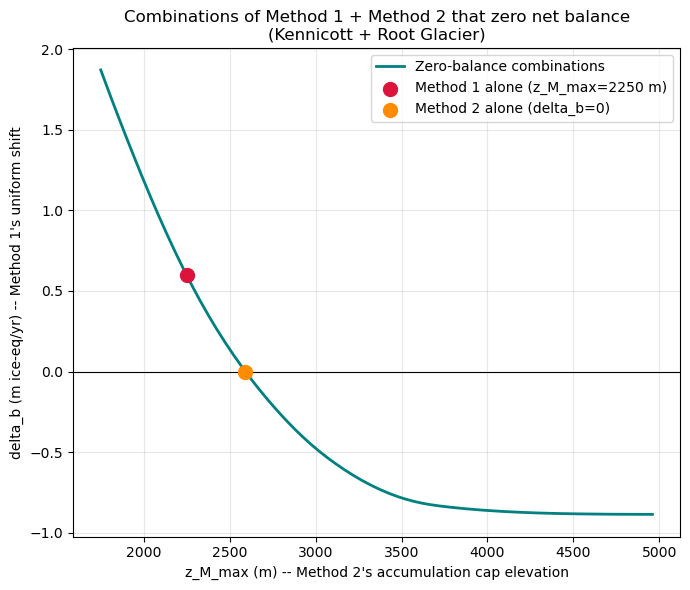

In [17]:
# For a given accumulation-cap elevation z_M_max (Method 2), the uniform
# shift delta_b (Method 1) needed to zero out the net balance has a closed
# form -- net balance is linear in delta_b, so no root-finding is needed.
def delta_b_for_combined_zero_balance(z_m_max_new, base_params, accum_gradient, bin_centers, area_km2_per_bin):
    params = make_accum_cap_params(z_m_max_new, base_params, accum_gradient)
    return -net_specific_balance(bin_centers, area_km2_per_bin, **params)


z_m_max_range = np.linspace(z_ela + 1, elevations.max() - 1, 200)
delta_b_range = np.array([
    delta_b_for_combined_zero_balance(z, PISM_PARAMS, accum_gradient, bin_centers, area_km2_per_bin)
    for z in z_m_max_range
])


def plot_combined_zero_balance(z_m_max_range, delta_b_range, pism_params,
                                z_m_max_zero, delta_b_zero):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(z_m_max_range, delta_b_range, color="teal", lw=2,
            label="Zero-balance combinations")
    ax.axhline(0, color="k", lw=0.8)
    ax.scatter([pism_params["z_M_max"]], [delta_b_zero], color="crimson", s=100, zorder=5,
               label=f"Method 1 alone (z_M_max={pism_params['z_M_max']:.0f} m)")
    ax.scatter([z_m_max_zero], [0], color="darkorange", s=100, zorder=5,
               label="Method 2 alone (delta_b=0)")
    ax.set_xlabel("z_M_max (m) -- Method 2's accumulation cap elevation")
    ax.set_ylabel("delta_b (m ice-eq/yr) -- Method 1's uniform shift")
    ax.set_title("Combinations of Method 1 + Method 2 that zero net balance\n(Kennicott + Root Glacier)")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_combined_zero_balance(z_m_max_range, delta_b_range, PISM_PARAMS, z_m_max_zero, delta_b_zero)


## Summary

- The Kennicott and Root Glacier outlines (`RGI60-01.15645`, `RGI60-01.26722`)
  were merged into a single outline, which was then used both to auto-download
  a mosaicked, UTM-7N-reprojected COP30 DEM and to clip that DEM to the
  combined ice extent for accurate, equal-area pixel statistics.
- Its hypsometry (area-elevation distribution) was combined with the
  PISM `elevation_dependent` piecewise-linear mass balance parameterization
  used for this glacier -- only `z_ELA` and one high-elevation point are
  actually observationally constrained (Petersen et al. 2025); `z_M_max` and
  `M_max` are an assumption, not a measurement.
- Two methods were used to find what it would take to zero out the net
  balance, each holding something different fixed: (1) a uniform shift of
  the entire profile (same gradients, same breakpoint elevations), and (2) a
  slide of the accumulation cap `(z_M_max, M_max)` along the fixed
  accumulation gradient, leaving the ablation zone untouched.
- Those two pure solutions are just the endpoints of a continuum: for any
  accumulation-cap elevation, there's exactly one uniform shift that,
  combined with it, zeros out the net balance. Mapping that whole family
  shows how much of the "fix" can come from a uniform shift versus from
  extending the accumulation zone further upslope.

Natural next steps: replace the piecewise-linear profile with an
observationally-calibrated one (e.g. from geodetic or stake mass-balance
data), or repeat this analysis through time using a DEM time series to see
how the zero-balance profile has shifted as the glacier has thinned.
